### Condición para que la reconstrucción sea única

La matriz $A \in \mathbb{R}^{m \times 64}$ transforma los 64 valores de los píxeles de la imagen en las $m$ mediciones obtenidas por los rayos:

$$
b = Ax
$$

Para que la imagen pueda reconstruirse de manera única, el sistema $Ax=b$ debe tener una única solución. Esto sucede cuando las 64 columnas de $A$ son linealmente independientes, es decir, cuando la matriz tiene rango columna completo:

$$
\operatorname{rango}(A)=64
$$

El espacio nulo de $A$ está formado por todos los vectores $v$ que cumplen:

$$
Av=0
$$

Si existe un vector no nulo $v$ tal que $Av=0$, entonces las imágenes representadas por $x$ y $x+v$ producen exactamente las mismas mediciones, porque:

$$
A(x+v)=Ax+Av=b+0=b
$$

Por lo tanto, las mediciones no permiten distinguir entre $x$ y $x+v$, y la reconstrucción no es única. El vector $v$ representa una modificación de la imagen que los rayos utilizados no pueden detectar.

Según el teorema de rango y nulidad:

$$
\operatorname{rango}(A)+\dim(\operatorname{Nul}(A))=64
$$

Por lo tanto:

$$
\dim(\operatorname{Nul}(A))=64-\operatorname{rango}(A)
$$

Si $\operatorname{rango}(A)=64$, entonces:

$$
\dim(\operatorname{Nul}(A))=0
$$

En ese caso, el espacio nulo contiene únicamente al vector cero y la reconstrucción puede ser única. En cambio, si $\operatorname{rango}(A)<64$, el espacio nulo contiene vectores no nulos y existen distintas imágenes capaces de producir las mismas mediciones.

Además, como:

$$
\operatorname{rango}(A)\leq \min(m,64)
$$

es necesario contar con al menos 64 rayos, es decir, $m\geq64$. Sin embargo, tener 64 rayos o más no garantiza por sí solo una reconstrucción única, ya que algunos rayos podrían aportar información repetida o linealmente dependiente.

16
(16, 64)


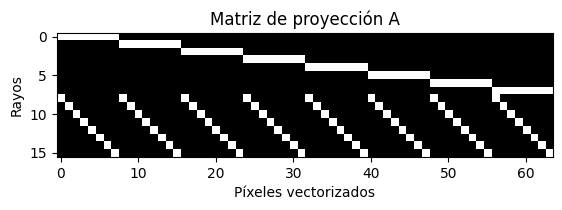

sip


In [1]:
%run ej3.ipynb



In [11]:
D2 = [(1, 0), (0, 1)]
A2, rayos_A2 = matriz_proyeccion(8, D2)
print (A2.shape)

rango_A2 = np.linalg.matrix_rank(A2)
print (rango_A2)

nul_A2 = 64 - rango_A2
print(nul_A2)

if (nul_A2 == 0):
    print ("Permite determinar una imagen de manera única!")
else :
    print ("No permite determinar una imagen de manera única!")





(16, 64)
15
49
No permite determinar una imagen de manera única!


In [12]:
D4 = D2 + [(1, 1), (1, -1)]
A4, rayos_A4 = matriz_proyeccion(8, D4)
print (A4.shape)

rango_A4 = np.linalg.matrix_rank(A4)
print (rango_A4)

nul_A4 = 64 - rango_A4
print(nul_A4)

if (nul_A4 == 0):
    print ("Permite determinar una imagen de manera única!")
else :
    print ("No permite determinar una imagen de manera única!")



(46, 64)
39
25
No permite determinar una imagen de manera única!


In [13]:
D7 = D4 + [(2, 1), (1, 2), (3, 1)]
A7, rayos_A7 = matriz_proyeccion(8, D7)
print (A7.shape)

rango_A7 = np.linalg.matrix_rank(A7)
print (rango_A7)

nul_A7 = 64 - rango_A7
print(nul_A7)

if (nul_A7 == 0):
    print ("Permite determinar una imagen de manera única!")
else :
    print ("No permite determinar una imagen de manera única!")

(119, 64)
64
0
Permite determinar una imagen de manera única!


### Comparación de las matrices de proyección

La matriz $A_2$ tiene dimensiones $16 \times 64$ y rango 15. Por lo tanto, la dimensión de su espacio nulo es 49 y no permite determinar una imagen de manera única. Además, como tiene 16 filas pero solamente 15 son linealmente independientes, presenta una medición redundante.

La matriz $A_4$ tiene dimensiones $46 \times 64$ y rango 39. En este caso, la dimensión del espacio nulo es 25, por lo que tampoco permite determinar una imagen de manera única. La diferencia entre sus 46 filas y su rango indica que existen 7 mediciones redundantes.

Finalmente, la matriz $A_7$ tiene dimensiones $119 \times 64$ y rango 64. Como alcanza el máximo rango posible y la dimensión de su espacio nulo es cero, permite determinar una imagen de manera única. Sin embargo, de las 119 mediciones, solamente 64 son linealmente independientes, por lo que las 55 restantes son redundantes y no aportan información nueva para determinar la unicidad de la solución.

En conclusión, agregar nuevas direcciones aumenta la cantidad de información disponible, pero no todos los rayos incorporados aportan información independiente. Solo en el caso de $A_7$ se alcanza rango 64 y, por lo tanto, se reúnen mediciones suficientes para reconstruir una imagen de $8 \times 8$ de manera única.
